# F1 SIS — Strategy Engine: Real-Time Strategy Evaluation & Full-Race Monte Carlo Scenario Simulation
### Adaptive AI Decision Intelligence Platform

> **Subsystem:** Strategy Engine (`src/strategy_engine/`)  
> **Primary Responsibility:** Generate feasible multi-lap strategies and simulate their full remaining-race outcome distributions under uncertainty.  
> **Mandatory Architectural Principle:** The Strategy Engine does **NOT** select, recommend, rank as a decision, or declare a "best" strategy.

---

## 1. System Purpose & Architectural Boundary

The **Strategy Engine** answers:
> **"What could happen under each feasible strategy through race completion?"**

The downstream **Decision Engine** will answer:
> **"Given these possible outcomes, what should we choose?"**

### End-to-End Decision Intelligence Flow

```text
                    CURRENT RACE STATE
                            ↓
                CANDIDATE STRATEGY GENERATION
                  (S01, S02, S03, S04, ...)
                            ↓
            FULL-RACE MONTE CARLO SCENARIO ROLLOUTS
                  (N rollouts per candidate)
                            ↓
             SIMULATED RACE-FINISH OUTCOME DISTRIBUTIONS
             (Expected position, variance, risks)
                            ↓
                 STRATEGY ENGINE OUTPUT
             [Evaluated Strategy Alternatives]
                            ↓
                    DECISION ENGINE
                            ↓
                Strategy / Action Selection
```

### Key Conceptual Separation: Candidate Generation vs Monte Carlo
- **Candidate Strategy Generator**: Creates the structural variety of feasible strategies (pit laps, compound sequences, stint lengths).
- **Monte Carlo Simulator**: Quantifies uncertainty by rolling out each candidate under stochastic race conditions (lap time variance, tyre wear progression, Safety Car hazard rates, opponent pit reactions) from current lap through race finish.
- **Strategy Evaluator**: Computes objective performance, uncertainty, and risk metrics for each candidate alternative.
- **Decision Engine (Downstream)**: Consumes the evaluated alternatives to make strategic and real-time tactical decisions (e.g., `PIT NOW` vs `STAY OUT`).

In [1]:
import sys
import json
import csv
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure src is in Python module search path
ROOT = Path.cwd()
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

# Project imports
from race_state.manager import RaceStateManager
from race_state.models import parse_lap_number, RaceState
from strategy_engine.types import StrategyEngineConfig, StrategyEngineResult
from strategy_engine.engine import StrategyEngine
from lap_time.adapter import LapTimeAdapter
from tyre_deg.adapter import TyreDegAdapter
from sc_risk.adapter import SCRiskAdapter
from opponent_model.model import OpponentModel
from opponent_model.mc_interface import MonteCarloOpponentInterface
from overtake.adapter import OvertakeAdapter

# =============================================================================
# Simulation Configuration Parameters
# =============================================================================
N_ROLLOUTS = 150          # Monte Carlo rollouts per candidate strategy
RANDOM_SEED = 42          # Deterministic simulation seed
RISK_PROFILE = "balanced" # Profile for multi-criteria descriptive metrics
EGO_DRIVER = "VER"        # Target driver for strategy evaluation (Max Verstappen)

print("Simulation Configuration:")
print(f"  * Rollouts per Strategy: {N_ROLLOUTS}")
print(f"  * Random Seed:           {RANDOM_SEED}")
print(f"  * Descriptive Profile:   {RISK_PROFILE}")
print(f"  * Target Driver:         {EGO_DRIVER}")
print(f"  * Simulation Horizon:    Full remaining race derived dynamically from RaceState")

Simulation Configuration:
  * Rollouts per Strategy: 150
  * Random Seed:           42
  * Descriptive Profile:   balanced
  * Target Driver:         VER
  * Simulation Horizon:    Full remaining race derived dynamically from RaceState


In [2]:
# =============================================================================
# Construct Authentic Race State from 2024 Italian Grand Prix (Monza)
# =============================================================================
csv_path = ROOT / "data_fastf1_v1" / "laps" / "2024" / "Italian_Grand_Prix.csv"

manager = RaceStateManager({
    "year": 2024,
    "grand_prix": "Italian Grand Prix",
    "location": "Monza",
    "total_laps_expected": 53,
    "race_id": "2024_Italian_GP",
})

with open(csv_path, newline="", encoding="utf-8") as f:
    raw_rows = list(csv.DictReader(f))

# Replay telemetry up to Lap 20 snapshot
TARGET_LAP = 20
for lap in range(1, TARGET_LAP + 1):
    lap_rows = [r for r in raw_rows if parse_lap_number(r.get("LapNumber")) == lap]
    if lap_rows:
        manager.update_from_rows(lap_rows)
        manager.commit_lap(lap)

state = manager.state
ego = state.participants.get(EGO_DRIVER)
remaining_laps = state.total_laps_expected - state.current_lap

gap_str = f"+{ego.gap_to_leader_seconds:.2f}s" if ego.gap_to_leader_seconds is not None else "LEADER (0.00s)"
track_t = f"{state.current_conditions.track_temp:.1f}°C" if state.current_conditions.track_temp is not None else "N/A"
air_t = f"{state.current_conditions.air_temp:.1f}°C" if state.current_conditions.air_temp is not None else "N/A"

print("=" * 75)
print(f"HISTORICAL RACE STATE SNAPSHOT: {state.grand_prix} ({state.location})")
print("=" * 75)
print(f"  * Current Lap:          Lap {state.current_lap} of {state.total_laps_expected}")
print(f"  * Remaining Laps:       {remaining_laps} laps to checkered flag (Full Race Horizon)")
print(f"  * Target Driver:        {ego.driver} ({ego.team})")
print(f"  * Current Position:     P{ego.position}")
print(f"  * Current Tyre:         {ego.compound} ({int(ego.tyre_life)} laps old)")
print(f"  * Gap to Leader:        {gap_str}")
print(f"  * Track Status:         {'Safety Car' if state.current_conditions.has_safety_car else 'Green Flag'}")
print(f"  * Track Temp / Air:     {track_t} / {air_t}")
print("=" * 75)

# Display authentic field classification at Lap 20 (Top 10)
field_data = []
for p in sorted(state.participants.values(), key=lambda x: x.position or 99)[:10]:
    field_data.append({
        "Position": f"P{p.position}",
        "Driver": p.driver,
        "Team": p.team,
        "Tyre Compound": p.compound,
        "Tyre Age": f"{int(p.tyre_life)} laps" if p.tyre_life is not None else "N/A",
        "Gap to Leader": f"+{p.gap_to_leader_seconds:.2f}s" if p.gap_to_leader_seconds is not None else "LEADER",
        "Last Lap Time": f"{p.last_lap_time_seconds:.3f}s" if p.last_lap_time_seconds is not None else "N/A",
        "Pit Stops": p.pit_count,
    })
df_field = pd.DataFrame(field_data)
display(df_field)

HISTORICAL RACE STATE SNAPSHOT: Italian Grand Prix (Monza)
  * Current Lap:          Lap 20 of 53
  * Remaining Laps:       33 laps to checkered flag (Full Race Horizon)
  * Target Driver:        VER (Red Bull Racing)
  * Current Position:     P1
  * Current Tyre:         HARD (20 laps old)
  * Gap to Leader:        LEADER (0.00s)
  * Track Status:         Green Flag
  * Track Temp / Air:     46.6°C / 32.8°C


,Position,Driver,Team,Tyre Compound,Tyre Age,Gap to Leader,Last Lap Time,Pit Stops
0,P1,VER,Red Bull Racing,HARD,20 laps,LEADER,85.559s,0
1,P2,PER,Red Bull Racing,HARD,20 laps,+2.64s,86.111s,0
2,P3,PIA,McLaren,HARD,4 laps,+8.72s,83.986s,2
3,P4,NOR,McLaren,HARD,6 laps,+10.47s,83.882s,2
4,P5,LEC,Ferrari,HARD,5 laps,+11.44s,83.826s,2
5,P6,SAI,Ferrari,HARD,1 laps,+20.66s,104.811s,2
6,P7,HAM,Mercedes,HARD,5 laps,+21.40s,84.640s,2
7,P8,OCO,Alpine,HARD,20 laps,+23.14s,87.326s,0
8,P9,BOT,Kick Sauber,HARD,21 laps,+31.10s,86.803s,0
9,P10,RUS,Mercedes,HARD,9 laps,+31.33s,85.504s,2


In [3]:
# =============================================================================
# Initialize Actual Foundational & Opponent Models
# =============================================================================
# 1. Lap Time Model Adapter
lt_adapter = LapTimeAdapter()

# 2. Tyre Degradation Model Adapter
tyre_adapter = TyreDegAdapter()

# 3. SC/VSC Historical Risk Prior Adapter
sc_prior_path = ROOT / "models" / "SC Estimation" / "sc_vsc_historical_prior.csv"
sc_adapter = SCRiskAdapter(str(sc_prior_path)) if sc_prior_path.exists() else None

# 4. Opponent Pit Decision Model & Monte Carlo Interface
opp_model = OpponentModel.load()
opp_interface = MonteCarloOpponentInterface(opp_model)

# 5. Overtake Probability & Dirty Air Model Adapter
overtake_adapter = OvertakeAdapter()

print("(OK) All 5 Upstream Models Initialized:")
print(f"  1. LapTimeAdapter:      {type(lt_adapter).__name__}")
print(f"  2. TyreDegAdapter:      {type(tyre_adapter).__name__}")
print(f"  3. SCRiskAdapter:       {type(sc_adapter).__name__} (Prior: {sc_prior_path.name if sc_prior_path.exists() else 'Default'})")
print(f"  4. OpponentInterface:   {type(opp_interface).__name__} wrapping {type(opp_model).__name__}")
print(f"  5. OvertakeAdapter:     {type(overtake_adapter).__name__}")

(OK) All 5 Upstream Models Initialized:
  1. LapTimeAdapter:      LapTimeAdapter
  2. TyreDegAdapter:      TyreDegAdapter
  3. SCRiskAdapter:       SCRiskAdapter (Prior: sc_vsc_historical_prior.csv)
  4. OpponentInterface:   MonteCarloOpponentInterface wrapping OpponentModel
  5. OvertakeAdapter:     OvertakeAdapter


In [4]:
# =============================================================================
# Instantiate Production Strategy Engine with Full Remaining-Race Horizon
# =============================================================================
config = StrategyEngineConfig(
    default_n_rollouts=N_ROLLOUTS,
    default_random_seed=RANDOM_SEED,
)

engine = StrategyEngine(
    config=config,
    lap_time_adapter=lt_adapter,
    tyre_deg_adapter=tyre_adapter,
    sc_risk_adapter=sc_adapter,
    opponent_interface=opp_interface,
    overtake_adapter=overtake_adapter,
    default_rollouts=N_ROLLOUTS,
    default_profile=RISK_PROFILE,
    random_seed=RANDOM_SEED,
)

print("(OK) Production StrategyEngine initialized:")
print(f"  1. Candidate Generator: {type(engine.candidate_generator).__name__}")
print(f"  2. Scenario Simulator:  {type(engine.simulator).__name__} (Default: Full Remaining Race)")
print(f"  3. Strategy Evaluator:  {type(engine.evaluator).__name__}")
print(f"  4. Result Formatter:    {type(engine.formatter).__name__}")

(OK) Production StrategyEngine initialized:
  1. Candidate Generator: CandidateStrategyGenerator
  2. Scenario Simulator:  RaceScenarioSimulator (Default: Full Remaining Race)
  3. Strategy Evaluator:  StrategyEvaluator
  4. Result Formatter:    StrategyResultFormatter


In [5]:
# =============================================================================
# Step 1: Generate Feasible Candidate Strategies
# =============================================================================
# Generates candidate strategy plans across the full remaining race distance.
candidates = engine.candidate_generator.generate_candidates(
    state=state,
    ego_driver=EGO_DRIVER,
)

cand_table = []
current_comp = ego.compound or "MEDIUM"
for c in candidates:
    compound_progression = " -> ".join([current_comp] + c.compounds)
    cand_table.append({
        "Strategy ID": c.strategy_id,
        "Strategy Name": c.name,
        "Stops": c.num_stops,
        "Pit Laps": str(c.pit_laps),
        "Compounds": compound_progression,
        "Tactical Intent": c.tactical_intent.capitalize(),
    })

df_candidates = pd.DataFrame(cand_table)
print(f"Generated {len(candidates)} feasible candidate strategies for {EGO_DRIVER}:")
display(df_candidates)

Generated 21 feasible candidate strategies for VER:


,Strategy ID,Strategy Name,Stops,Pit Laps,Compounds,Tactical Intent
0,S01,1-Stop: H->M (Undercut Now),1,[20],HARD -> MEDIUM,Undercut
1,S02,1-Stop: H->S (Nominal Window (+13 laps)),1,[33],HARD -> SOFT,Nominal
2,S03,1-Stop: H->M (Nominal Window (+13 laps)),1,[33],HARD -> MEDIUM,Nominal
3,S04,1-Stop: H->S (Overcut Extension (+24 laps)),1,[44],HARD -> SOFT,Overcut
4,S05,1-Stop: H->M (Overcut Extension (+24 laps)),1,[44],HARD -> MEDIUM,Overcut
5,S06,"2-Stop: H->S->S (Laps 20, 36)",2,"[20, 36]",HARD -> SOFT -> SOFT,Aggressive_pace
6,S07,"2-Stop: H->S->M (Laps 20, 36)",2,"[20, 36]",HARD -> SOFT -> MEDIUM,Aggressive_pace
7,S08,"2-Stop: H->S->H (Laps 20, 36)",2,"[20, 36]",HARD -> SOFT -> HARD,Aggressive_pace
8,S09,"2-Stop: H->M->S (Laps 20, 36)",2,"[20, 36]",HARD -> MEDIUM -> SOFT,Aggressive_pace
9,S10,"2-Stop: H->M->M (Laps 20, 36)",2,"[20, 36]",HARD -> MEDIUM -> MEDIUM,Aggressive_pace


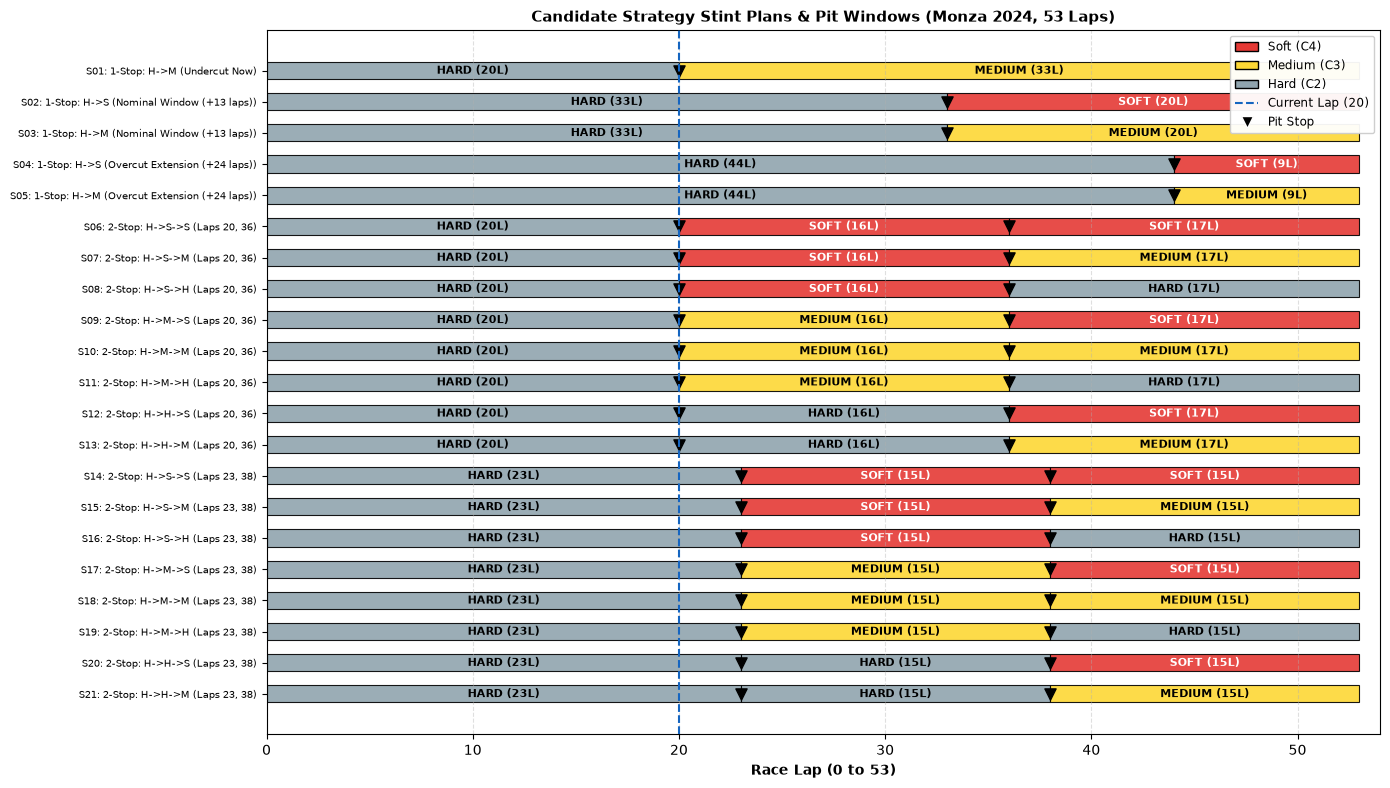

In [6]:
# =============================================================================
# Visualisation 1: Strategy Stint Timeline (Gantt-Style)
# =============================================================================
# Illustrates the stint breakdown, compound usage, and planned pit windows for
# all generated candidate strategies across the full 53 laps of the Grand Prix.
fig, ax = plt.subplots(figsize=(14, max(6.0, len(candidates) * 0.38)))

compound_colors = {
    "SOFT": "#E53935",    # Red
    "MEDIUM": "#FDD835",  # Yellow
    "HARD": "#90A4AE",    # Silver / Slate Gray
}

# Plot candidates in natural order from S01 (top) to S09 (bottom)
ordered_candidates = list(candidates)
y_ticks = []
y_labels = []

for idx, strat in enumerate(reversed(ordered_candidates)):
    y = idx
    y_ticks.append(y)
    y_labels.append(f"{strat.strategy_id}: {strat.name}")
    
    for stint in strat.stints:
        start = stint.start_lap
        width = stint.end_lap - stint.start_lap
        comp = stint.compound.upper()
        color = compound_colors.get(comp, "#78909C")
        
        ax.barh(y, width, left=start, height=0.55, color=color, edgecolor="black", linewidth=0.8, alpha=0.9)
        
        # Display compound label and stint length if segment width is sufficient
        if width >= 5:
            text_color = "black" if comp != "SOFT" else "white"
            ax.text(start + width / 2, y, f"{comp} ({width}L)", ha="center", va="center",
                    fontsize=8, fontweight="bold", color=text_color)
            
    # Mark planned pit stop laps with a marker
    for pl in strat.pit_laps:
        ax.scatter(pl, y, marker="v", color="black", s=65, zorder=5)

# Highlight the current committed snapshot lap
ax.axvline(state.current_lap, color="#1565C0", linestyle="--", linewidth=1.5, zorder=6,
           label=f"Current Lap ({state.current_lap})")

ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels, fontsize=max(6.5, 9.0 - len(candidates) * 0.1))
ax.set_xlabel("Race Lap (0 to 53)", fontweight="bold")
ax.set_xlim(0, state.total_laps_expected + 1)
ax.set_title("Candidate Strategy Stint Plans & Pit Windows (Monza 2024, 53 Laps)", fontsize=11, fontweight="bold")
ax.grid(True, axis="x", linestyle="--", alpha=0.4)

# Legend for tyre compounds and snapshot marker
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, color=compound_colors["SOFT"], ec="black", label="Soft (C4)"),
    plt.Rectangle((0, 0), 1, 1, color=compound_colors["MEDIUM"], ec="black", label="Medium (C3)"),
    plt.Rectangle((0, 0), 1, 1, color=compound_colors["HARD"], ec="black", label="Hard (C2)"),
    plt.Line2D([0], [0], color="#1565C0", linestyle="--", linewidth=1.5, label=f"Current Lap ({state.current_lap})"),
    plt.Line2D([0], [0], marker="v", color="w", markerfacecolor="black", markersize=8, label="Pit Stop"),
]
ax.legend(handles=legend_elements, loc="upper right", framealpha=0.95, fontsize=8.5)

plt.tight_layout()
plt.show()

In [7]:
# =============================================================================
# Step 2: Run Full Remaining-Race Monte Carlo Scenario Simulation
# =============================================================================
remaining_laps = state.total_laps_expected - state.current_lap
total_rollouts = len(candidates) * N_ROLLOUTS
print("Executing Full Remaining-Race Monte Carlo Scenario Simulation:")
print(f"  * Candidate Strategies:   {len(candidates)}")
print(f"  * Rollouts per Strategy:  {N_ROLLOUTS}")
print(f"  * Remaining-Lap Horizon:  {remaining_laps} laps (Laps {state.current_lap + 1} to {state.total_laps_expected} [Race Completion])")
print(f"  * Random Seed:            {RANDOM_SEED}")
print(f"  * Total Rollouts:         {total_rollouts}")

sim_results = engine.simulator.simulate_all(
    state=state,
    ego_driver=EGO_DRIVER,
    strategies=candidates,
    n_rollouts=N_ROLLOUTS,
    seed=RANDOM_SEED,
)

print(f"(OK) Completed {total_rollouts} rollouts across all {len(candidates)} candidate strategies through race finish.")

Executing Full Remaining-Race Monte Carlo Scenario Simulation:
  * Candidate Strategies:   21
  * Rollouts per Strategy:  150
  * Remaining-Lap Horizon:  33 laps (Laps 21 to 53 [Race Completion])
  * Random Seed:            42
  * Total Rollouts:         3150
(OK) Completed 3150 rollouts across all 21 candidate strategies through race finish.


In [8]:
# =============================================================================
# Step 3: Evaluate Candidates & Construct Outcome Dataframe (Race Finish Metrics)
# =============================================================================
# Evaluates each candidate across multi-criteria race-finish performance and risk dimensions.
engine_result = engine.evaluate_race_state(
    state=state,
    ego_driver=EGO_DRIVER,
    n_rollouts=N_ROLLOUTS,
    profile=RISK_PROFILE,
    seed=RANDOM_SEED,
)

# Build dynamic dataframe strictly from actual full-race simulation and evaluation results
outcome_rows = []
for ev in engine_result.strategies:
    s = ev.strategy
    sim = ev.simulation_result
    outcome_rows.append({
        "Strategy": s.strategy_id,
        "Pit Laps": str(s.pit_laps),
        "Compounds": " -> ".join([current_comp] + s.compounds),
        "Expected Position": round(sim.expected_position, 2),
        "Position Std": round(sim.std_position, 2),
        "Expected Race Time": round(sim.expected_time_seconds, 2),
        "Race Time Std": round(sim.std_time_seconds, 2),
        "P(Win)": round(sim.p_win, 3),
        "P(Podium)": round(sim.p_podium, 3),
        "P(Top 5)": round(sim.p_top5, 3),
        "Tyre Risk": round(sim.tyre_risk, 3),
        "Traffic Risk": round(sim.traffic_risk, 3),
        "Robustness": round(sim.robustness, 3),
    })

df_outcomes = pd.DataFrame(outcome_rows)
print("Evaluated Strategy Alternatives (Generated Dynamically from Full-Race Monte Carlo Output):")
print(f"All metrics evaluate outcomes at RACE FINISH (Lap {state.total_laps_expected}):")
display(df_outcomes)

Evaluated Strategy Alternatives (Generated Dynamically from Full-Race Monte Carlo Output):
All metrics evaluate outcomes at RACE FINISH (Lap 53):


,Strategy,Pit Laps,Compounds,Expected Position,Position Std,Expected Race Time,Race Time Std,P(Win),P(Podium),P(Top 5),Tyre Risk,Traffic Risk,Robustness
0,S01,[20],HARD -> MEDIUM,1.71,0.47,7624.48,473.51,0.293,1.000,1.000,0.941,0.156,0.907
1,S02,[33],HARD -> SOFT,1.79,0.40,7722.40,414.96,0.207,1.000,1.000,0.833,0.135,0.919
2,S03,[33],HARD -> MEDIUM,1.89,0.52,7703.44,434.06,0.167,0.987,1.000,0.588,0.173,0.896
3,S04,[44],HARD -> SOFT,2.81,1.94,7611.17,481.31,0.113,0.833,0.887,0.375,0.646,0.612
4,S05,[44],HARD -> MEDIUM,4.39,2.76,7647.43,467.56,0.060,0.493,0.787,0.265,0.921,0.447
5,S06,"[20, 36]",HARD -> SOFT -> SOFT,1.75,0.43,7670.30,449.38,0.253,1.000,1.000,0.708,0.145,0.913
6,S07,"[20, 36]",HARD -> SOFT -> MEDIUM,1.87,0.55,7648.99,470.28,0.227,1.000,1.000,0.500,0.183,0.890
7,S08,"[20, 36]",HARD -> SOFT -> HARD,4.96,1.70,7684.68,455.98,0.040,0.167,0.633,0.370,0.568,0.659
8,S09,"[20, 36]",HARD -> MEDIUM -> SOFT,1.81,0.58,7647.35,470.65,0.280,1.000,1.000,0.708,0.194,0.884
9,S10,"[20, 36]",HARD -> MEDIUM -> MEDIUM,3.63,1.52,7692.46,453.69,0.140,0.380,0.913,0.500,0.506,0.697


---
## 4. Visual Analysis: Candidate Outcome Distributions & Uncertainties

The following visualisations are generated strictly from the **actual full-race Monte Carlo simulation results** produced above.
- Candidate strategies are displayed in their **natural generator order**.
- No strategy is sorted into a "leaderboard", highlighted as a "winner", or labeled as "recommended".
- All outcome distributions reflect the complete race finish at **Lap 53**.

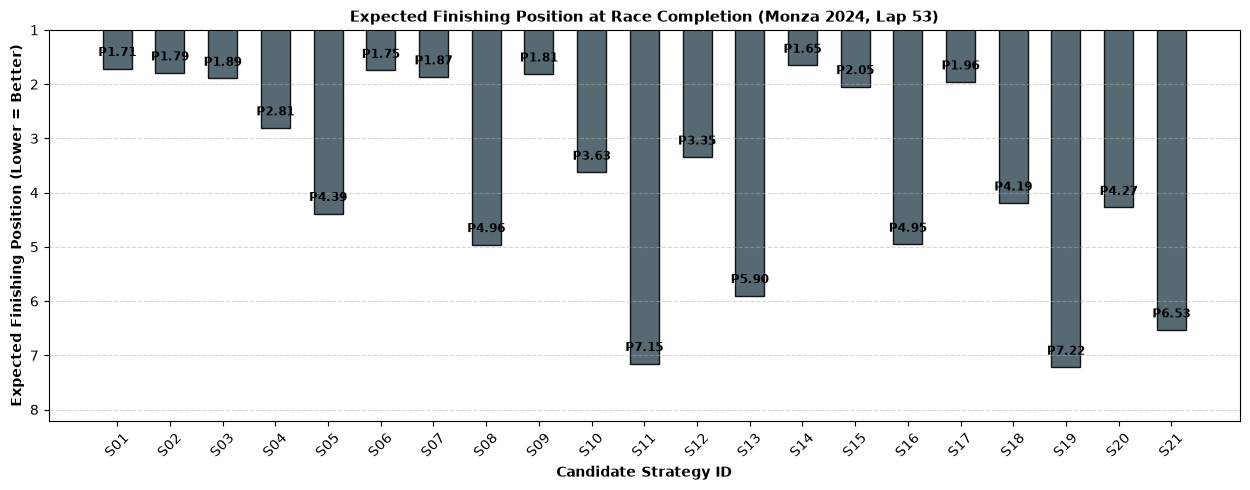

In [9]:
# =============================================================================
# Visualisation 2: Expected Finishing Position by Candidate Strategy
# =============================================================================
# Displays the mean expected finishing position across all Monte Carlo rollouts.
# Evaluated strategies are provided in deterministic neutral order.
evals = engine_result.strategies
strat_ids = [e.strategy.strategy_id for e in evals]
exp_positions = [e.simulation_result.expected_position for e in evals]

fig, ax = plt.subplots(figsize=(max(10, len(strat_ids) * 0.6), 5.0))
bars = ax.bar(strat_ids, exp_positions, color="#455A64", edgecolor="black", width=0.55, alpha=0.9)

# Invert Y-axis so P1 is at the top (standard motorsport convention)
ax.invert_yaxis()
ax.set_ylim(max(exp_positions) + 1.0, 1.0)
ax.set_xlabel("Candidate Strategy ID", fontweight="bold")
ax.set_ylabel("Expected Finishing Position (Lower = Better)", fontweight="bold")
ax.set_title("Expected Finishing Position at Race Completion (Monza 2024, Lap 53)", fontsize=11, fontweight="bold")
ax.grid(True, axis="y", linestyle="--", alpha=0.5)

# Annotate numerical expected position above each bar
for bar, val in zip(bars, exp_positions):
    ax.text(bar.get_x() + bar.get_width() / 2, val - 0.18, f"P{val:.2f}",
            ha="center", va="bottom", fontsize=8.5, fontweight="bold")

ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

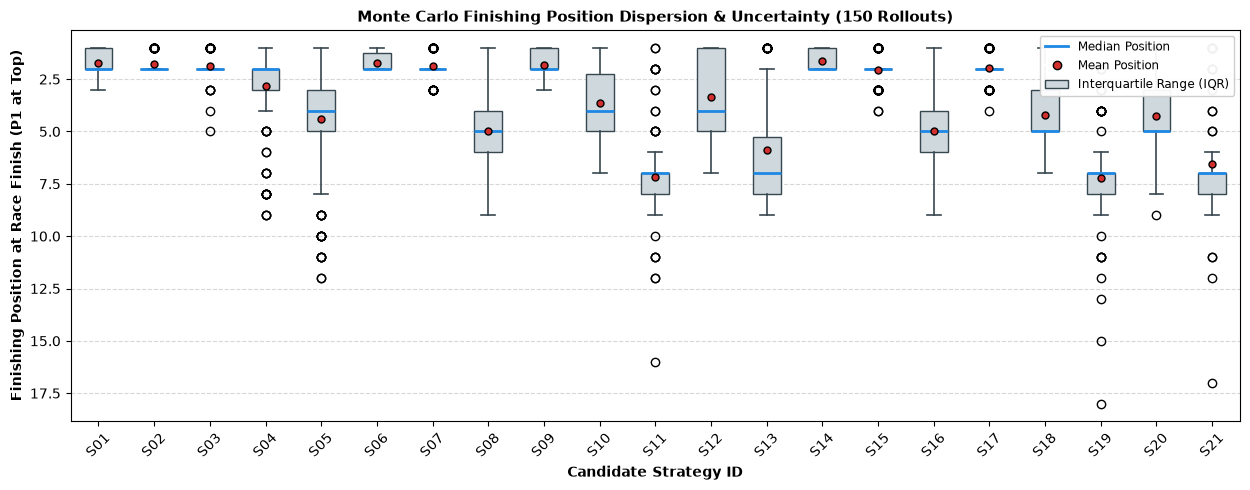

In [10]:
# =============================================================================
# Visualisation 3: Finishing Position Dispersion & Uncertainty (Box Plot)
# =============================================================================
# Illustrates the variance, median, IQR, and tail risk of finishing positions
# using actual rollout-level samples (150 rollouts per candidate).
pos_samples = [[r.final_position for r in e.simulation_result.rollouts] for e in evals]

fig, ax = plt.subplots(figsize=(max(10, len(strat_ids) * 0.6), 5.0))
bp = ax.boxplot(
    pos_samples,
    tick_labels=strat_ids,
    patch_artist=True,
    showmeans=True,
    boxprops=dict(facecolor="#CFD8DC", edgecolor="#37474F"),
    medianprops=dict(color="#1E88E5", linewidth=2.0),
    meanprops=dict(marker="o", markeredgecolor="black", markerfacecolor="#D32F2F", markersize=5),
    whiskerprops=dict(color="#37474F", linewidth=1.2),
    capprops=dict(color="#37474F", linewidth=1.2),
)

# Invert Y-axis so P1 is at the top
ax.invert_yaxis()
ax.set_xlabel("Candidate Strategy ID", fontweight="bold")
ax.set_ylabel("Finishing Position at Race Finish (P1 at Top)", fontweight="bold")
ax.set_title("Monte Carlo Finishing Position Dispersion & Uncertainty (150 Rollouts)", fontsize=11, fontweight="bold")
ax.grid(True, axis="y", linestyle="--", alpha=0.5)

# Add legend for median and mean markers
legend_elements = [
    plt.Line2D([0], [0], color="#1E88E5", linewidth=2.0, label="Median Position"),
    plt.Line2D([0], [0], marker="o", color="w", markeredgecolor="black", markerfacecolor="#D32F2F", markersize=6, label="Mean Position"),
    plt.Rectangle((0, 0), 1, 1, facecolor="#CFD8DC", edgecolor="#37474F", label="Interquartile Range (IQR)"),
]
ax.legend(handles=legend_elements, loc="upper right", framealpha=0.95, fontsize=8.5)

ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

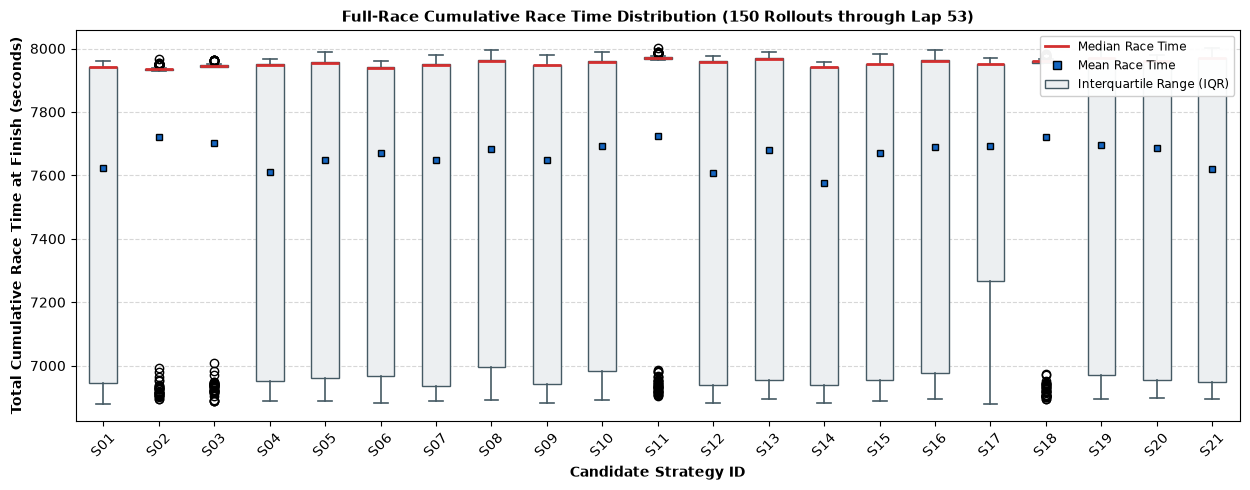

In [11]:
# =============================================================================
# Visualisation 4: Cumulative Race Time Distribution (Box Plot)
# =============================================================================
# Displays the distribution of cumulative race times across 150 rollouts through
# the 53-lap race finish (~7,600s). Uses actual rollout-level total race times.
time_samples = [[r.total_race_time_seconds for r in e.simulation_result.rollouts] for e in evals]

fig, ax = plt.subplots(figsize=(max(10, len(strat_ids) * 0.6), 5.0))
bp = ax.boxplot(
    time_samples,
    tick_labels=strat_ids,
    patch_artist=True,
    showmeans=True,
    boxprops=dict(facecolor="#ECEFF1", edgecolor="#455A64"),
    medianprops=dict(color="#D32F2F", linewidth=2.0),
    meanprops=dict(marker="s", markeredgecolor="black", markerfacecolor="#1565C0", markersize=5),
    whiskerprops=dict(color="#455A64", linewidth=1.2),
    capprops=dict(color="#455A64", linewidth=1.2),
)

ax.set_xlabel("Candidate Strategy ID", fontweight="bold")
ax.set_ylabel("Total Cumulative Race Time at Finish (seconds)", fontweight="bold")
ax.set_title("Full-Race Cumulative Race Time Distribution (150 Rollouts through Lap 53)", fontsize=11, fontweight="bold")
ax.grid(True, axis="y", linestyle="--", alpha=0.5)

# Add legend for median and mean markers
legend_elements = [
    plt.Line2D([0], [0], color="#D32F2F", linewidth=2.0, label="Median Race Time"),
    plt.Line2D([0], [0], marker="s", color="w", markeredgecolor="black", markerfacecolor="#1565C0", markersize=6, label="Mean Race Time"),
    plt.Rectangle((0, 0), 1, 1, facecolor="#ECEFF1", edgecolor="#455A64", label="Interquartile Range (IQR)"),
]
ax.legend(handles=legend_elements, loc="upper right", framealpha=0.95, fontsize=8.5)

ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

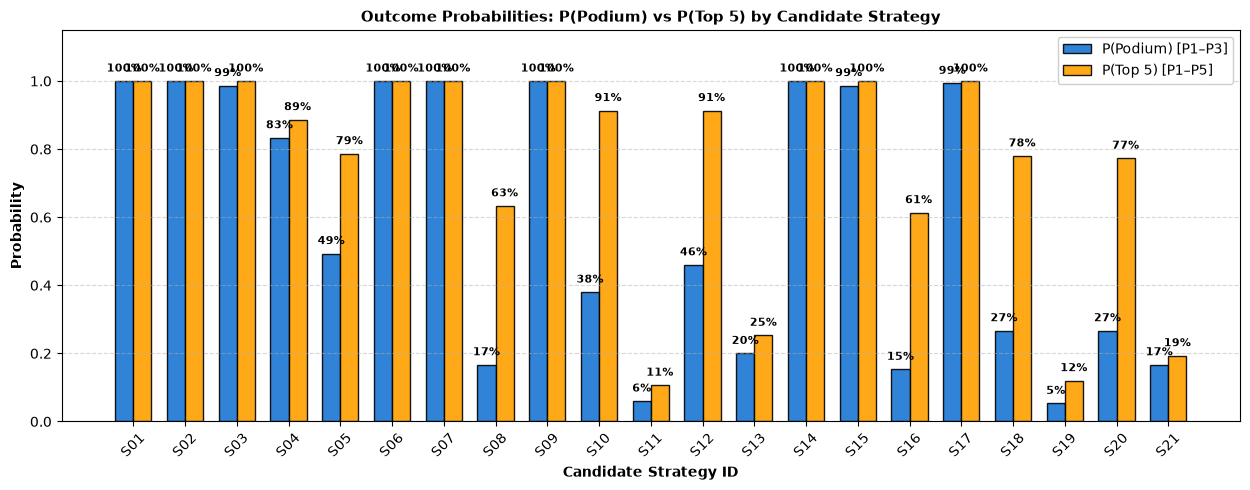

In [12]:
# =============================================================================
# Visualisation 5: Outcome Probabilities: P(Podium) vs P(Top 5)
# =============================================================================
# Compares the probability of finishing on the podium (P1-P3) and top 5 (P1-P5)
# derived from 150 Monte Carlo rollouts across all candidate strategies.
p_podium = [e.simulation_result.p_podium for e in evals]
p_top5 = [e.simulation_result.p_top5 for e in evals]

fig, ax = plt.subplots(figsize=(max(10, len(strat_ids) * 0.6), 5.0))
x = np.arange(len(strat_ids))
w = 0.35

bars_pod = ax.bar(x - w / 2, p_podium, width=w, label="P(Podium) [P1–P3]", color="#1976D2", edgecolor="black", alpha=0.9)
bars_t5 = ax.bar(x + w / 2, p_top5, width=w, label="P(Top 5) [P1–P5]", color="#FFA000", edgecolor="black", alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(strat_ids)
ax.set_ylim(0, 1.15)
ax.set_xlabel("Candidate Strategy ID", fontweight="bold")
ax.set_ylabel("Probability", fontweight="bold")
ax.set_title("Outcome Probabilities: P(Podium) vs P(Top 5) by Candidate Strategy", fontsize=11, fontweight="bold")
ax.legend(loc="upper right", framealpha=0.95)
ax.grid(True, axis="y", linestyle="--", alpha=0.5)

# Annotate percentage on each bar
for bar in list(bars_pod) + list(bars_t5):
    h = bar.get_height()
    if h > 0.02:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.02, f"{h * 100:.0f}%",
                ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [13]:
# =============================================================================
# Step 4: Strategy Engine Structured Output for Downstream Consumption
# =============================================================================
# The payload provides the evaluated alternatives and simulation metadata.
# It does NOT select, recommend, or declare a best strategy.
payload = engine_result.to_decision_engine_payload()

# Persist structured output to outputs/models for downstream Decision Engine consumption
output_dir = ROOT / "outputs" / "models"
output_dir.mkdir(parents=True, exist_ok=True)
output_file = output_dir / "strategy_engine_output.json"

with open(output_file, "w", encoding="utf-8") as f:
    json.dump(payload, f, indent=2)

print(f"(OK) Saved structured payload to: {output_file.relative_to(ROOT)}")
print("Simulation Metadata:")
print(f"  * Rollouts per Strategy: {payload['simulation_metadata']['rollouts_per_strategy']}")
print(f"  * Calculated Horizon:    {payload['simulation_metadata']['horizon_laps']} laps (Full Remaining Race to Finish)")
print(f"  * Random Seed:           {payload['simulation_metadata']['seed']}")
print("\nDownstream Decision Engine Payload (Sample Output):")
print(json.dumps(payload, indent=2))


(OK) Saved structured payload to: outputs\models\strategy_engine_output.json
Simulation Metadata:
  * Rollouts per Strategy: 150
  * Calculated Horizon:    33 laps (Full Remaining Race to Finish)
  * Random Seed:           42

Downstream Decision Engine Payload (Sample Output):
{
  "current_lap": 20,
  "ego_driver": "VER",
  "strategies": [
    {
      "strategy_id": "S01",
      "pit_laps": [
        20
      ],
      "compounds": [
        "MEDIUM"
      ],
      "expected_position": 1.71,
      "position_std": 0.47,
      "expected_race_time": 7624.48,
      "race_time_std": 473.51,
      "p_win": 0.2933,
      "p_podium": 1.0,
      "p_top5": 1.0,
      "tyre_risk": 0.9412,
      "traffic_risk": 0.1556,
      "robustness": 0.9067
    },
    {
      "strategy_id": "S02",
      "pit_laps": [
        33
      ],
      "compounds": [
        "SOFT"
      ],
      "expected_position": 1.79,
      "position_std": 0.4,
      "expected_race_time": 7722.4,
      "race_time_std": 414.96,
   